## Assignment 2 — Multiclass Text Classification

**Dataset:** ESG/SASB-Aligned ESG Sentences (Option 4)  
**Task:** Classify corporate ESG report sentences into 6 parent categories  
**Classes:** Human Capital | Leadership & Governance | Social Capital | Environment | Business Model & Innovation | Non-ESG  
**Size:** ~6,460 rows

In [1]:
import pandas as pd
import numpy as np
import re
import warnings
import time
warnings.filterwarnings('ignore')

# Visualizations
import matplotlib.pyplot as plt
import seaborn as sns

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

# Feature Engineering
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# ML Models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

# Evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, accuracy_score,
    f1_score, precision_score, recall_score
)
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

import os
os.makedirs('figures', exist_ok=True)


## Step 1: Import Data

In [2]:
# Load Dataset
df = pd.read_csv('esg_sasb_data.csv')
df.head(5)

,Text,Parent Label,Child Label
0,AB also recognizes the importance of carving a...,Human Capital,Employee Engagement Diversity & Inclusion
1,AB strives to create an environment in which e...,Human Capital,Employee Engagement Diversity & Inclusion
2,"Diversity, equity and inclusion (DEI) is a str...",Human Capital,Employee Engagement Diversity & Inclusion
3,"In our view, inclusive teams generate better i...",Human Capital,Employee Engagement Diversity & Inclusion
4,We continuously measure and monitor our progre...,Human Capital,Employee Engagement Diversity & Inclusion


## Step 2: Explanatory Data Analysis (EDA)

### 2.1 Metadata

In [3]:
# Data Overview
print(f'Dataset shape: {df.shape}')
print(f'Total rows     : {len(df):,}')
print(f'Total columns  : {len(df.columns)}')
print(f'Column names   : {df.columns}')
print(f'Missing values : {df.isnull().sum().sum()}')

Dataset shape: (6460, 3)
Total rows     : 6,460
Total columns  : 3
Column names   : Index(['Text', 'Parent Label', 'Child Label'], dtype='object')
Missing values : 0


In [4]:
# Parent Label
df['Parent Label'].value_counts()

,count
Parent Label,
Non-ESG,3546
Social Capital,882
Leadership & Governance,721
Environment,567
Human Capital,466
Business Model & Innovation,278


In [5]:
# Child Label
df['Child Label'].value_counts()

,count
Child Label,
Non-ESG,3546
Critical Incident Risk Management,337
Human Rights & Community Relations,275
Customer Welfare,231
Systemic Risk Management,211
Employee Engagement Diversity & Inclusion,196
Employee Health & Safety,192
GHG Emissions,183
Product Quality & Safety,167


### 2.2 Class Distribution


Class Distribution:
  Non-ESG                             3546
  Social Capital                      882
  Leadership & Governance             721
  Environment                         567
  Human Capital                       466
  Business Model & Innovation         278


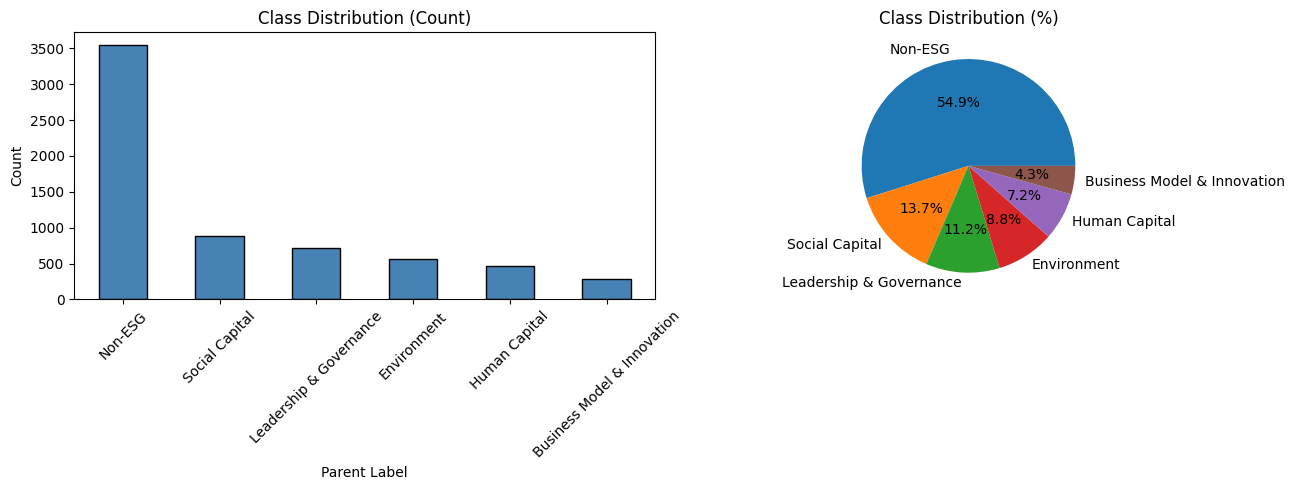

In [6]:
# Class Distribution
label_counts = df['Parent Label'].value_counts()

print('Class Distribution:')
for label, count in label_counts.items():
    print(f'  {label:<35} {count}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar Plot
label_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Class Distribution (Count)')
axes[0].set_xlabel('Parent Label')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Pie Chart
axes[1].pie(label_counts, labels=label_counts.index, autopct='%1.1f%%')
axes[1].set_title('Class Distribution (%)')

plt.tight_layout()
plt.show()

There are 6,460 rows in the dataset with 6 parent categories. As shown in the bar graph, the dataset is extremely imbalanced with 56% of the data being in the Non-ESG category. This imbalance could cause issues because even if a model achieves a high accuracy score, it could be simply predicting the majority class every time. In order to fix this, I used class_weight='balanced' for all the models.

### 2.3 Text Analysis by Class

Text Statistics by Class:
                            text_length                               word_count                            
                                   mean median min   max    std count       mean median min  max   std count
Parent Label                                                                                                
Business Model & Innovation       156.5  145.0  21   709   77.8   278       22.8   21.0   2  104  11.7   278
Environment                       162.5  148.0  19  1459  108.3   567       24.0   22.0   2  203  15.2   567
Human Capital                     152.6  140.0  16   856   89.1   466       22.8   21.0   2  124  12.5   466
Leadership & Governance           177.0  162.0  17   817   93.0   721       25.8   24.0   2  109  13.3   721
Non-ESG                           187.2  159.0  15  6129  181.8  3546       28.6   24.0   1  956  27.7  3546
Social Capital                    163.9  151.5  16   956   87.5   882       23.7   22.0   2  130  12.1

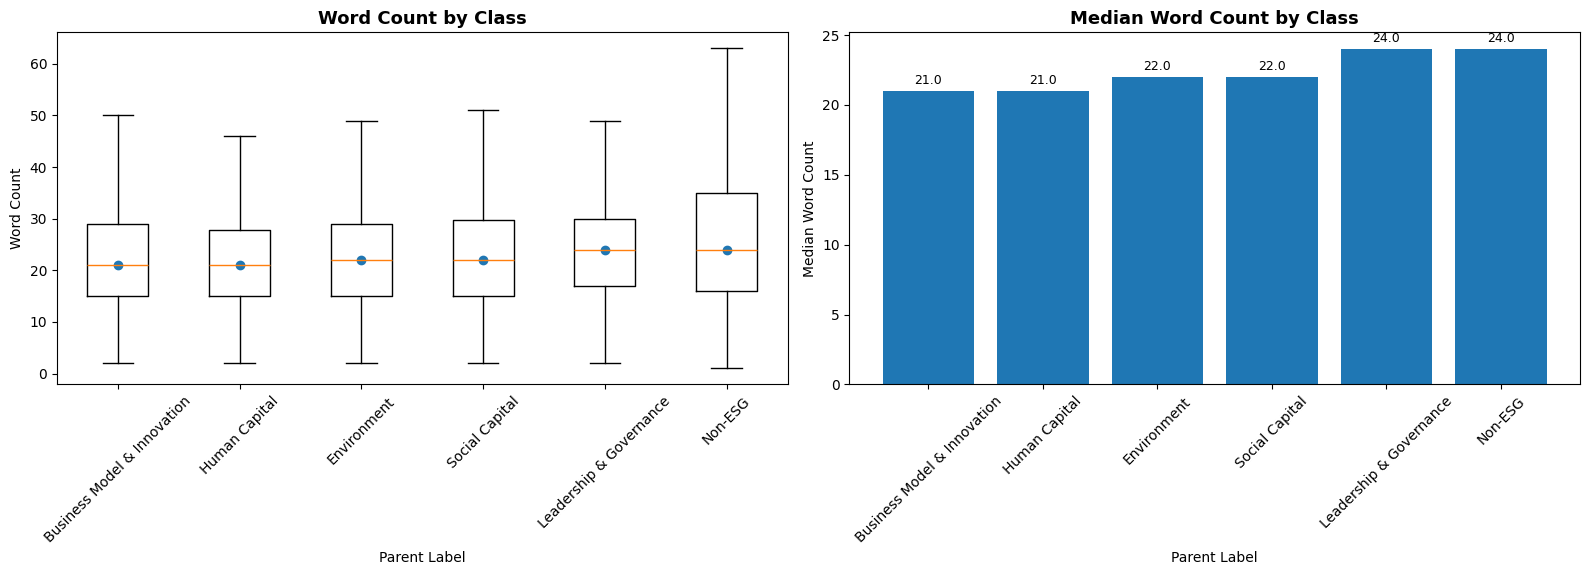

In [7]:
# Create text length features
df['text_length'] = df['Text'].astype(str).str.len()
df['word_count'] = df['Text'].astype(str).str.split().str.len()

# Summary stats
print('Text Statistics by Class:')
stats = (
    df.groupby('Parent Label')[['text_length', 'word_count']]
      .agg(['mean', 'median', 'min', 'max', 'std', 'count'])
      .round(1)
)
print(stats.to_string())

# Order labels by median word count
label_order = (
    df.groupby('Parent Label')['word_count']
      .median()
      .sort_values()
      .index
)

# Grouped data
grouped_word_counts = [
    df.loc[df['Parent Label'] == label, 'word_count'].dropna()
    for label in label_order
]

median_counts = (
    df.groupby('Parent Label')['word_count']
      .median()
      .reindex(label_order)
)

mean_counts = (
    df.groupby('Parent Label')['word_count']
      .mean()
      .reindex(label_order)
)
os.makedirs('figures', exist_ok=True)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot
axes[0].boxplot(
    grouped_word_counts,
    labels=label_order,
    patch_artist=False,
    showfliers=False
)
axes[0].set_title('Word Count by Class', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Parent Label')
axes[0].set_ylabel('Word Count')
axes[0].tick_params(axis='x', rotation=45)

axes[0].scatter(
    range(1, len(label_order) + 1),
    median_counts.values,
    marker='o'
)

# Median word count bar chart
axes[1].bar(label_order, median_counts.values)
axes[1].set_title('Median Word Count by Class', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Parent Label')
axes[1].set_ylabel('Median Word Count')
axes[1].tick_params(axis='x', rotation=45)

for i, v in enumerate(median_counts.values):
    axes[1].text(i, v + 0.5, f'{v:.1f}', ha='center', fontsize=9)

plt.suptitle('')
plt.tight_layout()

plt.savefig('figures/text_length_analysis.png', dpi=200, bbox_inches='tight')
plt.show()

The text length is relatively consistent across all the classes. Most of the sentences are about 20-40 words long, which makes sennse because the dataset contains a lot of individual corportate disclosure sentences rather than paragraphs.

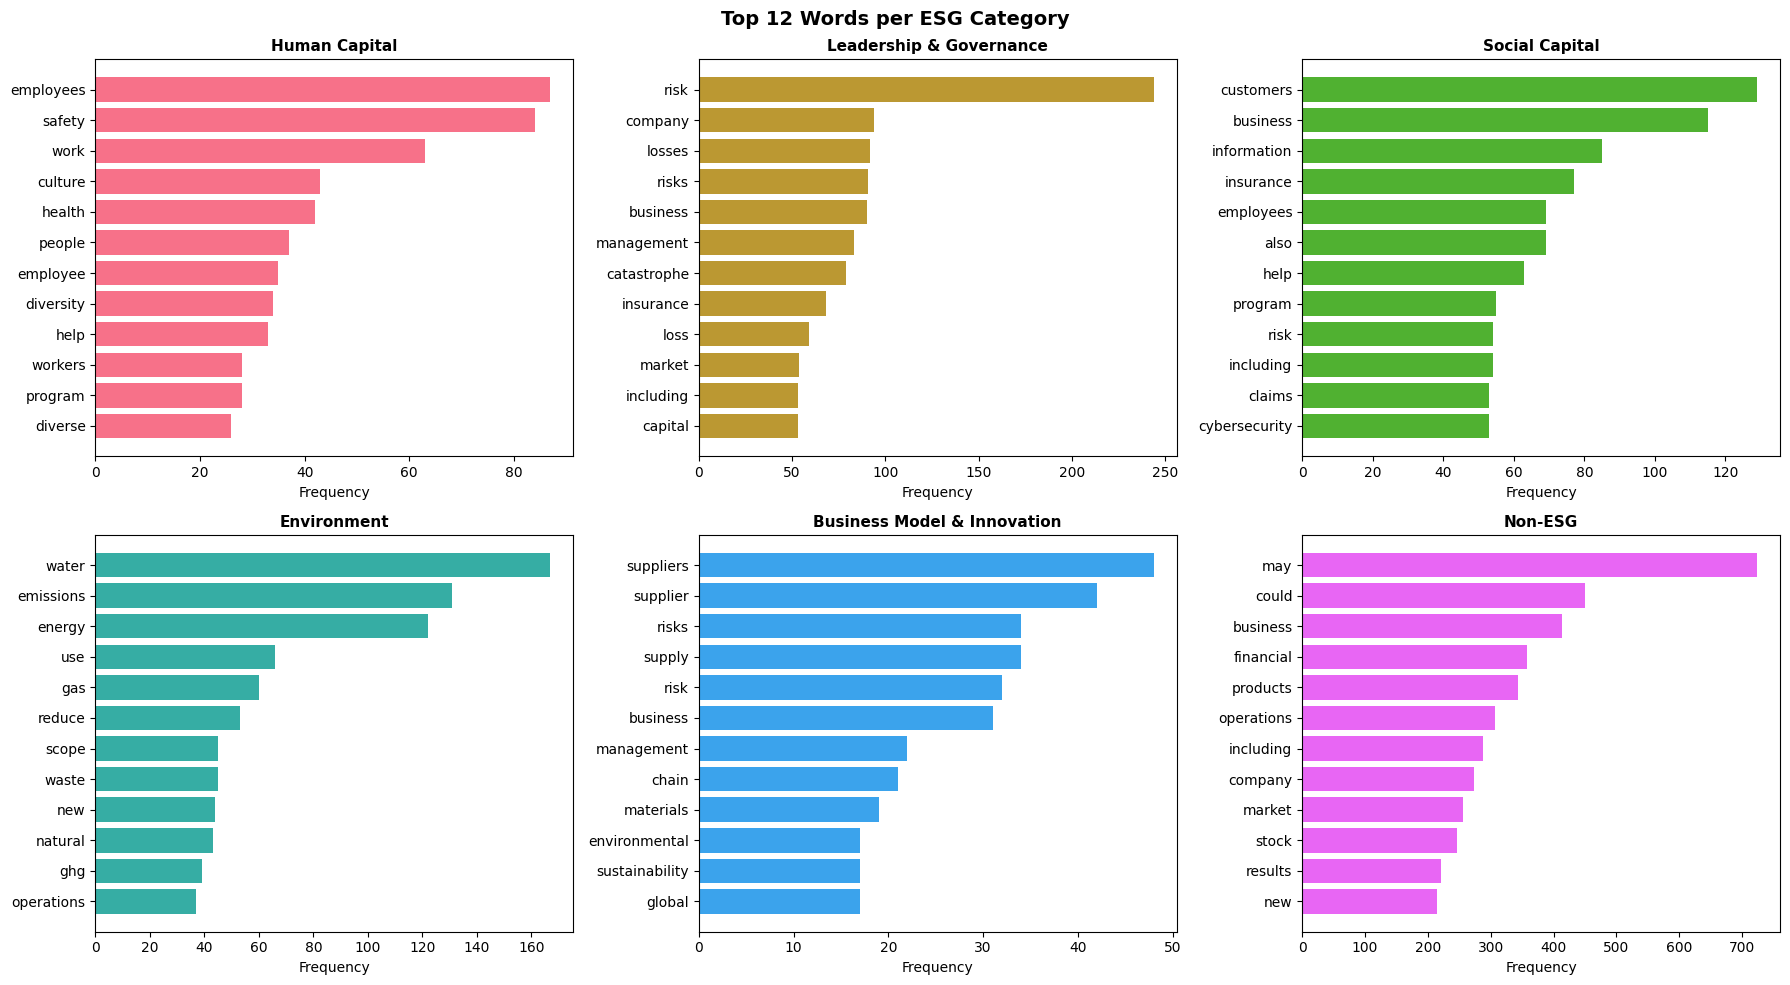

In [8]:
# Most Common Words per Class
from collections import Counter
import string

STOP_WORDS_EDA = set(stopwords.words('english'))

def get_top_words(texts, n=12):
    words = []
    for text in texts:
        tokens = str(text).lower().split()
        tokens = [t.strip(string.punctuation) for t in tokens]
        tokens = [t for t in tokens if t.isalpha() and
                  t not in STOP_WORDS_EDA and len(t) > 2]
        words.extend(tokens)
    return Counter(words).most_common(n)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
colors = sns.color_palette('husl', 6)

for i, label in enumerate(df['Parent Label'].unique()):
    subset = df[df['Parent Label'] == label]['Text']
    top_words = get_top_words(subset, n=12)
    words_list, counts_list = zip(*top_words)
    axes[i].barh(list(words_list)[::-1], list(counts_list)[::-1], color=colors[i])
    axes[i].set_title(label, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Frequency')

plt.suptitle('Top 12 Words per ESG Category', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/top_words_per_class.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 3: Text Cleaning & Preprocessing

### Design Decisions for ESG Text
Cleaning choices:

| Decision | Rationale |
|----------|-----------|
| Keep numbers and % | Critical metrics: '18% emission reduction' |
| Remove punctuation/special chars | No sarcasm signals needed (unlike sentiment) |
| Lemmatize | Reduces vocabulary without losing meaning ('managing' → 'manage') |
| Remove stopwords | 'the', 'and', 'of' carry no ESG signal |
| Lowercase | Standard normalization |
| Remove URLs/HTML | Not present in report text but defensive coding |


In [9]:
# Text Cleaning
lemmatizer = WordNetLemmatizer()
STOP_WORDS_SET = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'<[^>]+>', ' ', text)         # remove HTML
    text = re.sub(r'http\S+|www\S+', ' ', text) # remove URLs
    text = re.sub(r'\S+@\S+', ' ', text)         # remove emails
    text = re.sub(r'[^a-z0-9%\s]', ' ', text)   # keep letters, numbers, %
    text = re.sub(r'\s+', ' ', text).strip()    # normalize whitespace
    return text

def preprocess_text(text):
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(t) for t in tokens
              if t not in STOP_WORDS_SET and len(t) > 2]
    return ' '.join(tokens)

def full_pipeline(text):
    return preprocess_text(clean_text(text))

In [10]:
# Examples
for label in df['Parent Label'].unique():
    sample = df[df['Parent Label'] == label]['Text'].iloc[0]
    cleaned = full_pipeline(sample)
    print(f'\nClass: {label}')
    print(f'  BEFORE: {sample[:180]}')
    print(f'  AFTER : {cleaned[:180]}')
    print('-' * 70)


Class: Human Capital
  BEFORE: AB also recognizes the importance of carving and strengthening pathways for diverse talent within the firm, so we???ve implemented a series of initiatives aimed at providing both o
  AFTER : also recognizes importance carving strengthening pathway diverse talent within firm implemented series initiative aimed providing individual talent manager tool need effectively ma
----------------------------------------------------------------------

Class: Leadership & Governance
  BEFORE: AB employees have several pathways for securely reporting and escalating ethical, compliance or other concerns, including:  Formal reporting channels (a supervisor or manager) or t
  AFTER : employee several pathway securely reporting escalating ethical compliance concern including formal reporting channel supervisor manager compliance department general counsel office
----------------------------------------------------------------------

Class: Social Capital
  BEFORE: AB has 

In [11]:
df['cleaned_text'] = df['Text'].apply(full_pipeline)

# Remove any empty texts after cleaning
df = df[df['cleaned_text'].str.strip() != ''].reset_index(drop=True)
print(f'Rows after cleaning: {len(df):,}')
print(f'Empty texts remaining: {(df["cleaned_text"].str.strip() == "").sum()}')


Rows after cleaning: 6,459
Empty texts remaining: 0


## Step 4: Feature Engineering

We compare three feature extraction approaches:

| Method | Vocab Size | Captures Phrase Context? | Penalizes Common Words? |
|--------|-----------|------------------------|-----------------------|
| CountVectorizer (1-2 gram) | 7,000 | Partial (bigrams) | No |
| TF-IDF Bigrams | 10,000 | Yes | Yes |

**Vocabulary guidance:** Multiclass with 6 categories → 5,000–10,000 features (per assignment).


In [12]:
# Label Encoding
le = LabelEncoder()
df['label_enc'] = le.fit_transform(df['Parent Label'])

print('Label encoding:')
for i, cls in enumerate(le.classes_):
    count = (df['label_enc'] == i).sum()
    print(f'  {i} -> {cls:<35} ({count} rows)')

Label encoding:
  0 -> Business Model & Innovation         (278 rows)
  1 -> Environment                         (567 rows)
  2 -> Human Capital                       (466 rows)
  3 -> Leadership & Governance             (721 rows)
  4 -> Non-ESG                             (3545 rows)
  5 -> Social Capital                      (882 rows)


In [13]:
# Train-Test Split
X = df['cleaned_text']
y = df['label_enc']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f'Train size : {len(X_train):,} ({len(X_train)/len(df)*100:.1f}%)')
print(f'Test size  : {len(X_test):,}  ({len(X_test)/len(df)*100:.1f}%)')
print()
print('Stratification check (% per class in train vs test):')
for i, cls in enumerate(le.classes_):
    tr_pct = (y_train == i).sum() / len(y_train) * 100
    te_pct = (y_test  == i).sum() / len(y_test)  * 100
    print(f'  {cls:<35}  Train={tr_pct:.1f}%  Test={te_pct:.1f}%')

Train size : 5,167 (80.0%)
Test size  : 1,292  (20.0%)

Stratification check (% per class in train vs test):
  Business Model & Innovation          Train=4.3%  Test=4.3%
  Environment                          Train=8.8%  Test=8.7%
  Human Capital                        Train=7.2%  Test=7.2%
  Leadership & Governance              Train=11.2%  Test=11.1%
  Non-ESG                              Train=54.9%  Test=54.9%
  Social Capital                       Train=13.6%  Test=13.7%


In [14]:
# CountVectorizer
count_vec = CountVectorizer(max_features=7000, ngram_range=(1, 2), min_df=2)
X_train_count = count_vec.fit_transform(X_train)
X_test_count  = count_vec.transform(X_test)
print(f'  Shape: {X_train_count.shape}')
print(f'  Sample features: {count_vec.get_feature_names_out()[:10].tolist()}')

  Shape: (5167, 7000)
  Sample features: ['000', '000 000', '000 employee', '000 fiscal', '000 per', '000 proceeds', '000 respectively', '000 share', '000 square', '000 vehicle']


In [15]:
# TF-IDF (Bigrams)

tfidf_bi = TfidfVectorizer(max_features=10000, ngram_range=(1, 2),
                           min_df=2, sublinear_tf=True)
X_train_tfidf_bi = tfidf_bi.fit_transform(X_train)
X_test_tfidf_bi  = tfidf_bi.transform(X_test)
print(f'  Shape: {X_train_tfidf_bi.shape}')
print(f'  Sample bigrams: {[f for f in tfidf_bi.get_feature_names_out() if " " in f][:10]}')


  Shape: (5167, 10000)
  Sample bigrams: ['000 000', '000 employee', '000 fiscal', '000 per', '000 proceeds', '000 respectively', '000 share', '000 square', '000 vehicle', '10 net']


In [16]:
# Comparison
fe_results = {}
feature_sets = {
    'CountVectorizer': (X_train_count, X_test_count),
    'TF-IDF (Bigram)': (X_train_tfidf_bi, X_test_tfidf_bi),
}

for name, (Xtr, Xte) in feature_sets.items():
    m = LogisticRegression(class_weight='balanced', max_iter=500, random_state=42)
    m.fit(Xtr, y_train)
    preds = m.predict(Xte)
    f1  = f1_score(y_test, preds, average='weighted')
    acc = accuracy_score(y_test, preds)
    fe_results[name] = {'F1': round(f1, 4), 'Accuracy': round(acc, 4)}
    print(f'  {name:<30}  F1={f1:.4f}  Acc={acc:.4f}')

best_fe = max(fe_results, key=lambda k: fe_results[k]['F1'])
print(f'\nBest feature approach: {best_fe}')


  CountVectorizer                 F1=0.7787  Acc=0.7786
  TF-IDF (Bigram)                 F1=0.7938  Acc=0.7902

Best feature approach: TF-IDF (Bigram)


TF-IDF performed slightly better overall and can capture phrases like "carbon emission", "diversity inclusion", and "scope 3", which are highly discriminative in ESG text. I also made sure that frequent terms do not dominate the feature space. However, CountVectorizer can be more beneficial for models like Naive Bayes because it relies on raw word frequency counts.

## Step 5: Model Training

In [17]:
# Class Weights
classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, weights))

print('Computed class weights:')
for i, w in class_weight_dict.items():
    print(f'  {le.classes_[i]:<35} weight = {w:.3f}')

Computed class weights:
  Business Model & Innovation         weight = 3.879
  Environment                         weight = 1.897
  Human Capital                       weight = 2.309
  Leadership & Governance             weight = 1.492
  Non-ESG                             weight = 0.304
  Social Capital                      weight = 1.222


In [18]:
# Model 1: Logistic Regression
t0 = time.time()

lr_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    C=1.0,
    solver='lbfgs',
    multi_class='multinomial',
    random_state=42
)
lr_model.fit(X_train_tfidf_bi, y_train)
lr_time = time.time() - t0

y_pred_lr = lr_model.predict(X_test_tfidf_bi)
lr_f1  = f1_score(y_test, y_pred_lr, average='weighted')
lr_acc = accuracy_score(y_test, y_pred_lr)

print("Model Run Success")

Model Run Success


In [31]:
# Model 2: Naive Bayes (MultinomialNB)
t0 = time.time()

nb_model = MultinomialNB(alpha=0.1)
nb_model.fit(X_train_count, y_train)
nb_time = time.time() - t0

y_pred_nb = nb_model.predict(X_test_count)
nb_f1  = f1_score(y_test, y_pred_nb, average='weighted')
nb_acc = accuracy_score(y_test, y_pred_nb)

print("Model Run Success")

Model Run Success


In [20]:
# Model 3: SVM
t0 = time.time()

svm_model = LinearSVC(
    class_weight='balanced',
    C=1.0,
    max_iter=2000,
    random_state=42
)
svm_model.fit(X_train_tfidf_bi, y_train)
svm_time = time.time() - t0

y_pred_svm = svm_model.predict(X_test_tfidf_bi)
svm_f1  = f1_score(y_test, y_pred_svm, average='weighted')
svm_acc = accuracy_score(y_test, y_pred_svm)

print("Model Run Success")

Model Run Success


In [21]:
# Performance Threshold Check
for name, preds in [('Logistic Regression', y_pred_lr),
                     ('Naive Bayes',         y_pred_nb),
                     ('Linear SVC',          y_pred_svm)]:
    f1_w  = f1_score(y_test, preds, average='weighted')
    prec  = precision_score(y_test, preds, average='weighted')
    rec   = recall_score(y_test, preds, average='weighted')
    meets = any([f1_w >= 0.70, prec >= 0.70, rec >= 0.70])
    status = 'PASS' if meets else 'FAIL'
    print(f'  {name:<25}  F1={f1_w:.3f}  Prec={prec:.3f}  Rec={rec:.3f}  [{status}]')


  Logistic Regression        F1=0.794  Prec=0.800  Rec=0.790  [PASS]
  Naive Bayes                F1=0.813  Prec=0.817  Rec=0.810  [PASS]
  Linear SVC                 F1=0.813  Prec=0.812  Rec=0.817  [PASS]


## Step 6: Evaluation & Comparison

### 6.1 Classification Report

In [22]:
# Store model predictions
models_preds = [
    ('Logistic Regression', y_pred_lr),
    ('Naive Bayes', y_pred_nb),
    ('SVM', y_pred_svm),
]

# Classification report for each model ----
for name, preds in models_preds:
    print(f'\n{"="*60}')
    print(f'{name} Classification Report')
    print(f'{"="*60}')
    print(classification_report(y_test, preds, target_names=le.classes_))


Logistic Regression Classification Report
                             precision    recall  f1-score   support

Business Model & Innovation       0.49      0.52      0.50        56
                Environment       0.77      0.78      0.77       113
              Human Capital       0.69      0.71      0.70        93
    Leadership & Governance       0.65      0.69      0.67       144
                    Non-ESG       0.91      0.86      0.88       709
             Social Capital       0.64      0.74      0.69       177

                   accuracy                           0.79      1292
                  macro avg       0.69      0.72      0.70      1292
               weighted avg       0.80      0.79      0.79      1292


Naive Bayes Classification Report
                             precision    recall  f1-score   support

Business Model & Innovation       0.64      0.62      0.63        56
                Environment       0.78      0.84      0.81       113
              Human C

### 6.2 Confusion Matrix

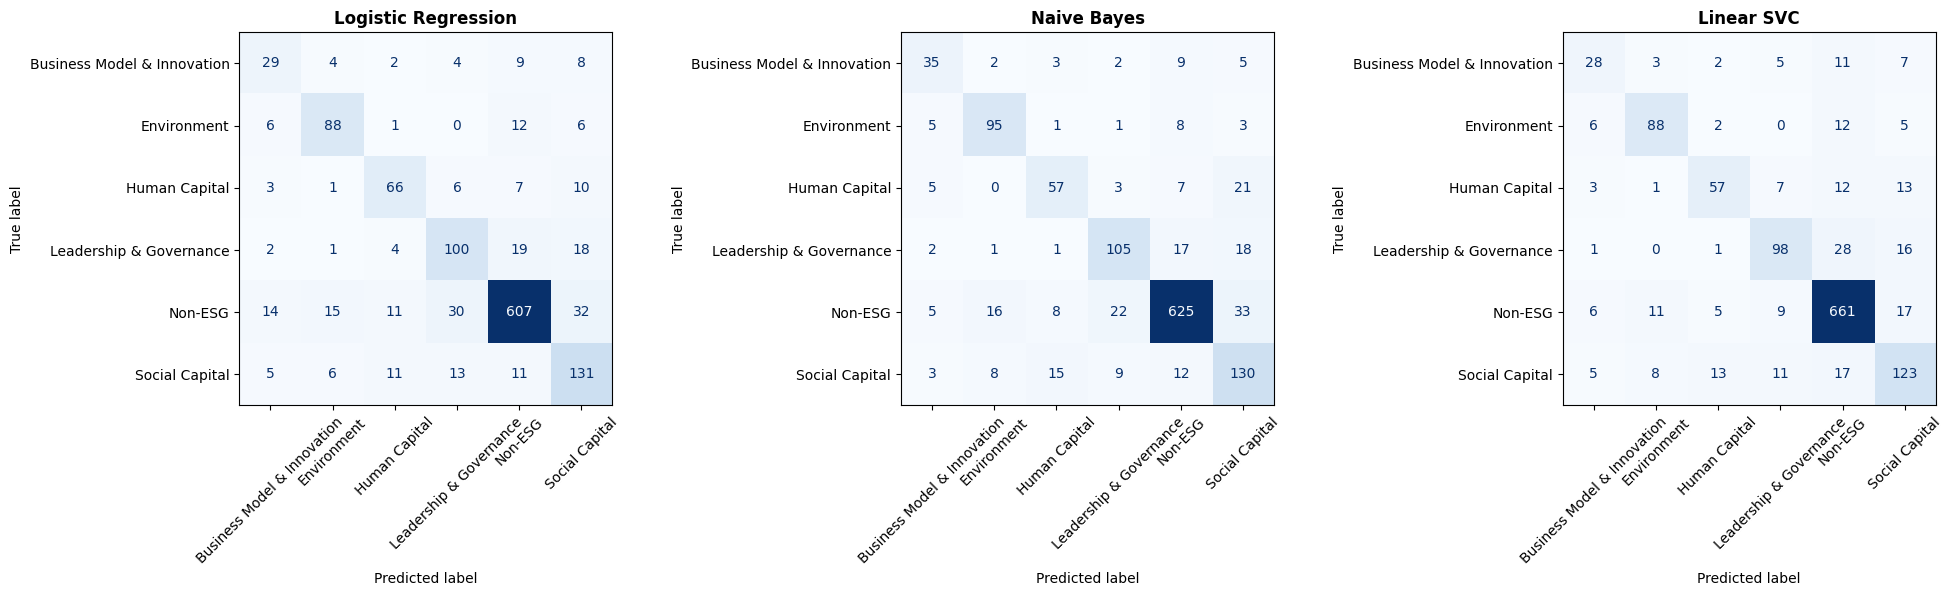

In [23]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Store model predictions
models_preds = [
    ('Logistic Regression', y_pred_lr),
    ('Naive Bayes', y_pred_nb),
    ('Linear SVC', y_pred_svm),
]

# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, (name, preds) in zip(axes, models_preds):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

The confusion matrices showed that the model performed the best on Non-ESG, likely due to class imbalance (majority of the data fall into this category). The models achieved relatively high accuracy/precision as the diagonals contain very high numbers. It is also evident that Logistic Regression had the most misclassifications, indicating that it is not a good model to use.

### 6.3 Important Class

The most important class is **Environment**. This category is critical because environmental risks and disclosures often have significant regulatory and financial implications for organizations. Missing environmental-related content could lead to underestimating exposure to climate-related risks or sustainability obligations.

Between precision and recall, **recall** is more important for this class. It is more costly to miss an environmental-related text (false negative) than to incorrectly classify a non-environmental text as environmental (false positive). This is because failing to identify environmental risks can lead to compliance or regulatory issues.

When comparing the model performance, **Naive Bayes** is the best as it achieved a higher F1-score than the others. Even though SVM has a higher overall accuracy, Naive Bayes is a better model because it provides stronger performance on the most important class.

### 6.4 Random 20-Row Review

In [24]:
# 20 Random Reviews
np.random.seed(42)
sample_idx = np.random.choice(len(X_test), size=20, replace=False)

X_test_reset = X_test.reset_index(drop=True)

# Text and model prediction
review_df = pd.DataFrame({
    'Text': [X_test_reset.iloc[idx] for idx in sample_idx],
    'Model Prediction': [le.classes_[y_pred_nb[idx]] for idx in sample_idx],
    'My Label': ''  # Fill in Excel
})

review_df.index = range(1, 21)
review_df.to_excel('random_esg_reviews.xlsx', index_label='#')
print('Exported to random_esg_reviews.xlsx')

Exported to random_esg_reviews.xlsx


In [25]:
# Compare Predicted & True Label
filled_df = pd.read_csv('manual_review.csv')
filled_df.columns = filled_df.columns.str.strip()  # safety

agree_count = 0

for i, row in filled_df.iterrows():
    match = 'CORRECT' if row['My Label'] == row['Model Prediction'] else 'WRONG'

    if match == 'CORRECT':
        agree_count += 1

    print(f'{i:<3} {row["My Label"]:<35} {row["Model Prediction"]:<35} {match}')

print(f'\nMatch: {agree_count}/20 ({agree_count*5}%)')

0   Leadership & Governance             Non-ESG                             WRONG
1   Business Model & Innovation         Business Model & Innovation         CORRECT
2   Leadership & Governance             Non-ESG                             WRONG
3   Non-ESG                             Non-ESG                             CORRECT
4   Leadership & Governance             Non-ESG                             WRONG
5   Non-ESG                             Non-ESG                             CORRECT
6   Social Capital                      Business Model & Innovation         WRONG
7   Social Capital                      Social Capital                      CORRECT
8   Non-ESG                             Non-ESG                             CORRECT
9   Environment                         Environment                         CORRECT
10  Non-ESG                             Non-ESG                             CORRECT
11  Social Capital                      Social Capital                      CORRECT


The model correctly predicted 15/20 of the random reviews.

When looking at the incorrect predictions, some patterns that I noticed were:

- The model struggled with borderline cases, especially those with similar ESG categories such as Governance and Human Capital.
- Some errors occurred when the text contained generic business language without clear ESG-specific keywords, leading to misclassification.
- The model occasionally overpredicted more common classes, indicating a slight bias toward higher-frequency categories.
- Short or vague text inputs were more likely to be misclassified due to limited contextual information.

The model performs well on clearly defined ESG content, but has difficulty with ambiguous or overlapping categories. This means that additional context or more advanced feature engineering could help improve performance.

### 6.5 5-Criteria Comparison

In [26]:
# Comparison Table
lr_report  = classification_report(y_test, y_pred_lr,  target_names=le.classes_, output_dict=True)
nb_report  = classification_report(y_test, y_pred_nb,  target_names=le.classes_, output_dict=True)
svm_report = classification_report(y_test, y_pred_svm, target_names=le.classes_, output_dict=True)

print(f'{"Criterion":<30} {"Logistic Regression":<25} {"Naive Bayes":<22} {"SVM"}')
print('-' * 90)

rows = [
    ('1. Weighted F1',
     f'{lr_report["weighted avg"]["f1-score"]:.3f}',
     f'{nb_report["weighted avg"]["f1-score"]:.3f}',
     f'{svm_report["weighted avg"]["f1-score"]:.3f}'),
    ('2. Training Time',
     f'{lr_time:.2f}s',
     f'{nb_time:.4f}s',
     f'{svm_time:.2f}s'),
    ('3. Environment F1',
     f'{lr_report["Environment"]["f1-score"]:.3f}',
     f'{nb_report["Environment"]["f1-score"]:.3f}',
     f'{svm_report["Environment"]["f1-score"]:.3f}'),
    ('4. Interpretability',
     'High (coefficients)',
     'Medium (log-prob)',
     'Low (no probs)'),
    ('5. Scalability',
     'Good (linear solver)',
     'Excellent',
     'Good (sparse)'),
]

for row in rows:
    print(f'{row[0]:<30} {row[1]:<25} {row[2]:<22} {row[3]}')

Criterion                      Logistic Regression       Naive Bayes            SVM
------------------------------------------------------------------------------------------
1. Weighted F1                 0.794                     0.813                  0.813
2. Training Time               1.11s                     0.0278s                0.11s
3. Environment F1              0.772                     0.809                  0.786
4. Interpretability            High (coefficients)       Medium (log-prob)      Low (no probs)
5. Scalability                 Good (linear solver)      Excellent              Good (sparse)


I would recommend Naive Bayes as the best final model for this task. Although SVM has slightly higher overall accuracy, Naive Bayes achieves the highest F1-score on the Environment class, which is the most important class in this analysis. It is also the fastest model to train, making it a strong choice for this assignment. Logistic Regression is the most interpretable, but it performs worse overall than the other two models.

## Step 7: Custom Inference

### 7.1 Create 20 Examples

In [27]:
custom_examples = [
    # ── EASY (10) ──────────────────────────────────────────────────────────
    "The company reduced Scope 1 greenhouse gas emissions by 21% after upgrading equipment and increasing its use of renewable electricity.",
    "Water withdrawals fell by 14% across manufacturing sites due to expanded recycling and conservation systems.",
    "Hazardous waste disposal declined year over year as the company improved waste tracking and handling procedures.",
    "The employee injury rate decreased by 25% following new workplace safety training and stricter operating standards.",
    "More than 90% of employees participated in leadership development and technical skills training programs this year.",
    "Customer information is protected through annual cybersecurity training, stronger encryption, and multi-factor authentication.",
    "The company expanded access to lower-cost financial products in underserved communities through new branch and digital service offerings.",
    "The board's audit committee reviewed enterprise risk management practices and approved updates to the anti-corruption policy.",
    "Executive compensation includes performance goals tied to ethics, compliance, and long-term sustainability targets.",
    "The company redesigned product packaging to reduce material use and improve recyclability across several major product lines.",

    # ── TRICKY (5) ────────────────────────────────────────────────────────
    "The company invested heavily in electric delivery vehicles, which lowered fuel costs while also reducing fleet emissions.",
    "Management introduced a supplier code of conduct to improve labor standards and reduce reputational risk across the supply chain.",
    "A new telehealth platform made care more accessible to rural patients while raising additional concerns around privacy protections.",
    "The CEO's annual incentive payout now depends partly on achieving diversity goals across senior leadership roles.",
    "The company said it remains committed to responsible business practices, but it did not disclose any measurable targets or outcomes.",

    # ── DIFFERENT CONTEXT (5) ─────────────────────────────────────────────
    "A property insurer offers premium discounts for homeowners who install storm-resistant roofs and wildfire mitigation upgrades.",
    "A pharmaceutical company stated that its therapies must pass extensive clinical trials and regulatory review before approval.",
    "Quarterly revenue increased 11% because of higher prices and stronger consumer demand across several brands.",
    "The new smartphone model comes in five colors, features a lighter design, and includes a faster processor.",
    "A logistics company strengthened board oversight of climate risk after flooding disrupted regional warehouse operations."
]

expected_labels = [
    # EASY (10)
    "Environment",                  # 1
    "Environment",                  # 2
    "Environment",                  # 3
    "Human Capital",                # 4
    "Human Capital",                # 5
    "Social Capital",               # 6
    "Social Capital",               # 7
    "Leadership & Governance",      # 8
    "Leadership & Governance",      # 9
    "Business Model & Innovation",  # 10

    # TRICKY (5)
    "Environment",                  # 11
    "Business Model & Innovation",  # 12
    "Social Capital",               # 13
    "Human Capital",                # 14
    "Non-ESG",                      # 15

    # DIFFERENT CONTEXT (5)
    "Social Capital",               # 16
    "Leadership & Governance",      # 17
    "Non-ESG",                      # 18
    "Non-ESG",                      # 19
    "Leadership & Governance"       # 20
]

difficulty = ["Easy"] * 10 + ["Tricky"] * 5 + ["Out-of-domain"] * 5


### 7.2 Run Inference

In [28]:
# Preprocess
X_new_cleaned = [full_pipeline(t) for t in custom_examples]

# Vectorize
X_new_vec = count_vec.transform(X_new_cleaned)

# Predict using final model
y_new_pred = nb_model.predict(X_new_vec)
y_new_labels = le.inverse_transform(y_new_pred)

print("Inference complete!")

Inference complete!


### 7.3 Evaluate & Reflect

In [29]:
results = []
correct = 0
for i, (text, expected, predicted, diff) in enumerate(
        zip(custom_examples, expected_labels, y_new_labels, difficulty)):
    is_correct = (expected == predicted)
    if is_correct:
        correct += 1
    results.append({
        '#':          i + 1,
        'Difficulty': diff,
        'Text':       text[:65] + '...',
        'Expected':   expected,
        'Predicted':  predicted,
        'Correct':    'YES' if is_correct else 'NO',
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))
print()
print(f'SCORE: {correct}/20 correct ({correct*5}%)')

print('\nBreakdown by difficulty:')
for diff_type in ['Easy', 'Tricky', 'Out-of-domain']:
    subset = [r for r in results if r['Difficulty'] == diff_type]
    n_correct = sum(1 for r in subset if r['Correct'] == 'YES')
    print(f'  {diff_type:<15}: {n_correct}/{len(subset)}')


 #    Difficulty                                                                 Text                    Expected                   Predicted Correct
 1          Easy The company reduced Scope 1 greenhouse gas emissions by 21% after...                 Environment                 Environment     YES
 2          Easy Water withdrawals fell by 14% across manufacturing sites due to e...                 Environment                 Environment     YES
 3          Easy Hazardous waste disposal declined year over year as the company i...                 Environment                 Environment     YES
 4          Easy The employee injury rate decreased by 25% following new workplace...               Human Capital               Human Capital     YES
 5          Easy More than 90% of employees participated in leadership development...               Human Capital               Human Capital     YES
 6          Easy Customer information is protected through annual cybersecurity tr...              S

**Q1: How many did the model get right?**

The model accurately predicted 13/20 (65%). This is significantly lower than the test data, which means that the model could be slightly overfitted or needs to be trained on more diverse data.

**Q2: Did the model fail on tricky examples?**

The model was able to correctly classify 4/5 of the tricky examples, which is relatively great. The one misclassified example was more generic, which led the model to predict Environment when it was really Non-ESG. This could be because words like "responsible" are more associated with Environment when it comes to ESG content.

**Q3: Did the model handle out-of-domain examples?**

The model performed poorly on the out-of-domain examples, only correctly predicting 1/5. Since the examples were written with a different style/wording than the corporate ESG reports, it was much harder for the model to correctly label it. This is true because I used bag-of-words representation, which can only recognize patterns from the training data.

**Q4: What does this tell us about generalization?**

The model is good for classifying single-company ESG report sentences, but does not perform well when the sentences are outside the scope of the training data. This tells us that the performance depends heavily on the quality and diversity of training data.

**Q5: Would you trust this model in prediction?**

I think that this model could be good as a decision-support tool rather than using a fully automated system. It could be effective for simple internal ESG report processing. However, for larger scale regulatory use, human review would still be needed. To improve this model, we could incorporate more advanced NLP models (e.g., word embeddings) or improve the class balance of the dataset.